In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
X = np.load('../data/processed/tracks_scaled.npy')

print(X.shape)
print(X.dtype)

(114000, 8)
float64


In [3]:
# Taking a representative sample of the data for faster computation - specifically for determination of k (we'll later fit the whole dataset with the chosen k)
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=10000, replace=False)
X_sample = X[sample_idx]

print(X_sample.shape)

(10000, 8)


In [4]:
K_RANGE = range(2, 13)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=2000, random_state=42))

    print(f'k={k:2d} | inertia={km.inertia_:,.1f} | silhouette={sil_scores[-1]:.4f}')

k= 2 | inertia=65,705.1 | silhouette=0.2184
k= 3 | inertia=57,531.2 | silhouette=0.1834
k= 4 | inertia=51,609.2 | silhouette=0.1878
k= 5 | inertia=47,103.7 | silhouette=0.1949
k= 6 | inertia=43,060.8 | silhouette=0.1979
k= 7 | inertia=39,355.6 | silhouette=0.2065
k= 8 | inertia=37,117.4 | silhouette=0.1915
k= 9 | inertia=34,969.9 | silhouette=0.1955
k=10 | inertia=33,357.5 | silhouette=0.1823
k=11 | inertia=32,016.9 | silhouette=0.1877
k=12 | inertia=30,944.1 | silhouette=0.1791


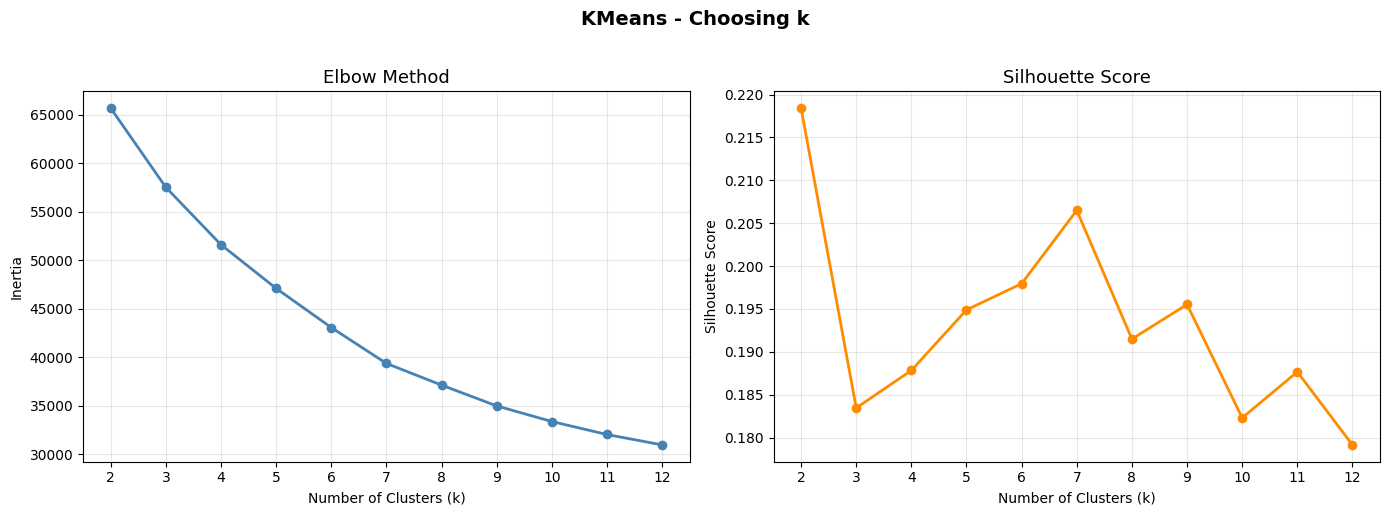

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ks = list(K_RANGE)

#Elbow
ax1.plot(ks, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method', fontsize=13)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(ks)
ax1.grid(True, alpha=0.3)

#Silhouette
ax2.plot(ks, sil_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score', fontsize=13)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(ks)
ax2.grid(True, alpha=0.3)

plt.suptitle("KMeans - Choosing k", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/05_kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

> This is a very typical elbow curve for real-world audio data — no sharp bend, just a gradual flattening. 

The slope is steepest from k=2 to k=5, then starts tapering. The 6–7 zone is where the curve transitions from "dropping meaningfully" to "diminishing returns."

Elbow: Soft inflection around k=6–7
Silhouette: k=7 is the secondary peak (0.2065) 

k=2 does wins on silhouette numerically, but two clusters isn't a useful segmentation for music as it would produce something like "chill vs. energetic" and nothing more interesting. k=7 gives you enough clusters to find meaningfully distinct audio archetypes without over-fragmenting.

> Both signals agree on k=7 so **we go with k=7**.

In [6]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Labels shape: ", cluster_labels.shape)
print("Unique clusters: ", np.unique(cluster_labels))

# Distribution of tracks across clusters
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'Cluster {c}: {n:,} tracks ({n/len(X)*100:.1f}%)')

Labels shape:  (114000,)
Unique clusters:  [0 1 2 3 4 5 6]
Cluster 0: 8,421 tracks (7.4%)
Cluster 1: 33,149 tracks (29.1%)
Cluster 2: 7,737 tracks (6.8%)
Cluster 3: 22,445 tracks (19.7%)
Cluster 4: 24,203 tracks (21.2%)
Cluster 5: 6,274 tracks (5.5%)
Cluster 6: 11,771 tracks (10.3%)


In [7]:
np.save('../data/processed/cluster_labels.npy', cluster_labels)
print("Saved cluster_labels.npy")

Saved cluster_labels.npy


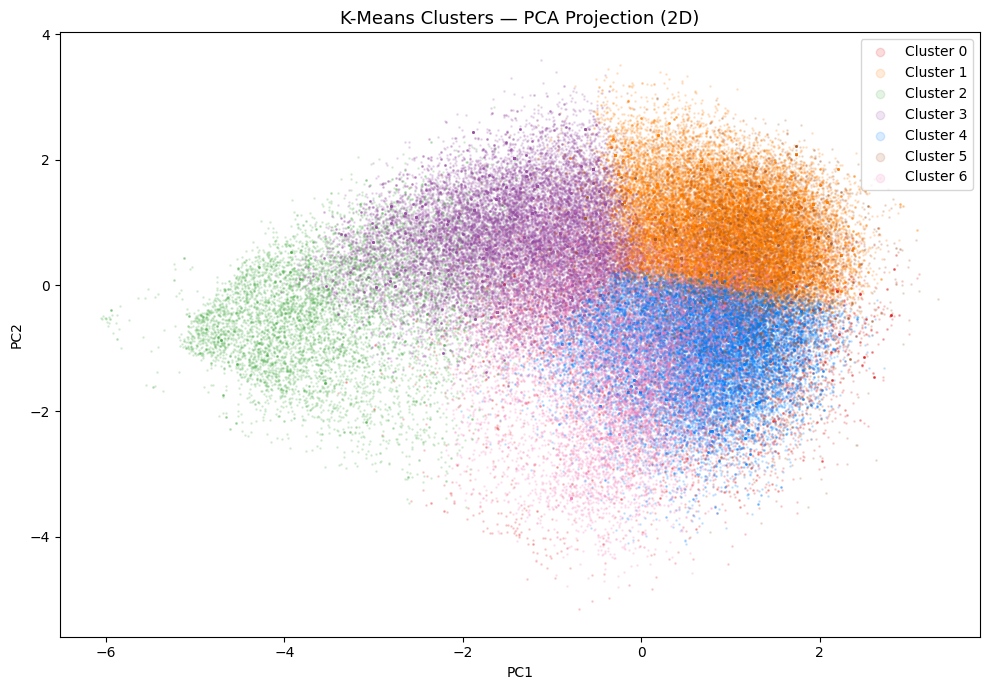

In [21]:
# Load PCA coordinates (computed in preprocessing)
X_pca = np.load("../data/processed/tracks_pca.npy")

# Color palette — 7 distinct colors
colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#984ea3', '#0080ff', '#a65628', '#f781bf']

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in range(7):
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.15,
        s=1
    )

ax.set_title("K-Means Clusters — PCA Projection (2D)", fontsize=13)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=6, loc='upper right')
plt.tight_layout()
plt.savefig("../outputs/figures/06_cluster_pca.png", dpi=150, bbox_inches='tight')
plt.show()